# **Level 2 (Intermediate) — Task 2: Classification with Logistic Regression**

**Internship:** Codveda Virtual Data Science Internship  
**Level:** 2 — Intermediate | **Task:** 2 of 2  
**Tools:** Python, scikit-learn, pandas, matplotlib, seaborn  
**Dataset:** Iris Dataset — 150 rows (147 after deduplication), 5 columns, 3 target classes

---

## Project Overview

The Iris dataset is one of the most studied classification benchmarks in machine learning, and for good reason — it is small, clean, and perfectly structured to illustrate how different classification algorithms behave. Each row represents a single iris flower described by four physical measurements: sepal length, sepal width, petal length, and petal width. The task is to predict which of three species — *setosa*, *versicolor*, or *virginica* — that flower belongs to.

This is a **multiclass classification** problem: the target variable is a category with more than two possible values, and the model must learn to distinguish between all three simultaneously. What makes it interesting is that while setosa is linearly separable from the other two, versicolor and virginica share overlapping feature ranges — meaning a model's real test is how well it resolves that boundary.

---

## Task Objectives

1. Load, inspect, and clean the Iris dataset
2. Perform exploratory data analysis to understand feature distributions and class separability
3. Build and evaluate three classification models: **Logistic Regression** (primary), **Random Forest**, and **Support Vector Machine (SVM)**
4. Apply appropriate preprocessing per model — scaling for Logistic Regression and SVM, unscaled data for Random Forest
5. Evaluate all models on **accuracy**, **precision**, and **recall**
6. Visualise performance using a multiclass **ROC curve (one-vs-rest)** for all three models on a single plot
7. Compare model performance and draw data-driven conclusions

---

## Notebook Structure

| Phase | Description |
|-------|-------------|
| Phase 1 | Imports |
| Phase 2 | Load and Inspect Data |
| Phase 3 | Data Cleaning |
| Phase 4 | Exploratory Data Analysis |
| Phase 5 | Feature / Target Split and Train/Test Split |
| Phase 6 | Scaling (LR and SVM only) |
| Phase 7 | Logistic Regression |
| Phase 8 | Random Forest |
| Phase 9 | SVM |
| Phase 10 | Model Comparison Table |
| Phase 11 | ROC Curves |
| Phase 12 | Written Insights |


## **PHASE 1 — Imports**

> **What this phase does:** Loads every library this notebook depends on — data manipulation, visualisation, and all scikit-learn components for modelling, preprocessing, and evaluation.
>
> **Why it's structured this way:** All imports are grouped at the top so the notebook can be run top-to-bottom without any missing dependency errors mid-way. `warnings.filterwarnings('ignore')` suppresses convergence warnings that do not affect results — they are noise, not errors. The `LabelBinarizer` and ROC imports are included upfront even though they are only used in Phase 11, because it is cleaner to declare all dependencies together.
>
> **Note:** The `plot_boxplots()` helper function defined below is a reusable utility that accepts any dataframe and list of features. Defining it here, at the top of the notebook, means it is available the moment it is needed in Phase 4 — no risk of a `NameError` if cells are re-run out of order.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

In [35]:
def plot_boxplots(df, features, target='species'):
    """
    Plots a 2x2 grid of boxplots comparing each Iris feature across the three species classes.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    axes = axes.flatten()

    # Professional Palette
    palette = sns.color_palette("colorblind")

    # The Loop
    for i, col in enumerate(features):
        sns.boxplot(
            data=df,
            x=target,
            y=col,
            ax=axes[i],
            palette=palette,
            hue=target, # Avoids future warnings
            legend=False,
            width=0.6,
            fliersize=4 # Size of the outlier dots
        )

        # Styling
        axes[i].set_title(f"{col.replace('_', ' ').title()} by {target}", fontsize=14, weight='bold')
        axes[i].set_xlabel("Species", fontsize=10)
        axes[i].set_ylabel("Value", fontsize=10)
        sns.despine(ax=axes[i])


    plt.tight_layout(pad=3.0)
    plt.show()


## **PHASE 2 — Load and Inspect Data**

> **What this phase does:** Loads the Iris CSV from Google Drive and performs a systematic first-look inspection — structure, data types, class distribution, and descriptive statistics.
>
> **Why this matters:** Before writing a single line of model code, we need to understand what we are working with. `.info()` tells us column types and whether any values are missing at the dtype level. `.describe()` gives the numerical ranges of each feature — important for understanding whether scaling will matter. `value_counts()` on the species column is the first check of class balance. If one class had far fewer examples than the others, we would need to account for that during modelling.


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Codveda task dataset/1) iris.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# checking for class balance
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [6]:
# summary stats
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## **PHASE 3 — Data Cleaning**

> **What this phase does:** Detects and removes duplicate rows, then re-verifies the dataset is still clean after the operation.
>
> **Why duplicates are dropped:** A duplicate row is a data integrity issue — it means the same observation appears more than once, which can bias a model by giving certain examples more influence during training than they deserve. The Iris dataset has 3 exact duplicates. After dropping them, the dataset has 147 rows. The class counts shift slightly: setosa drops to 48, virginica to 49, versicolor stays at 50 — all three duplicates happened to belong to setosa and virginica. This is not a class imbalance problem; the counts are still close enough that no correction is needed.
>
> **Why `reset_index(drop=True)`:** After dropping rows, the index still holds the original row numbers with gaps. Resetting gives a clean 0-to-146 index, which prevents any unexpected index-alignment issues downstream.


In [10]:
# Checking for duplicate rows
df.duplicated().sum()

# dropping duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# confirming new shape
df.shape

(147, 5)

In [12]:
#  Re-check vlaue count of target
df['species'].value_counts()

,count
species,
versicolor,50
virginica,49
setosa,48


In [13]:
# Re-confirm null count is still 0 after drop
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


## **PHASE 4 — EDA**

> **What this phase does:** Explores the cleaned dataset visually — class distribution, and how each feature's values differ across the three species.
>
> **Why EDA comes before modelling:** A model trained blind to the data structure often produces results that are correct but unexplainable. EDA tells us *which features are likely to matter*, *whether the classes are separable at all*, and *what kind of decision boundary a model will need to draw*. The count plot confirms class balance. The boxplots are where the real insight lives — if petal length and petal width show tight, non-overlapping distributions across species, those features will be strong predictors. If sepal width shows overlapping distributions, it will contribute less signal.
>
> **Observation from the boxplots:** Petal length and petal width show the clearest separation between all three species — setosa clusters at very low values with no overlap. Versicolor and virginica overlap moderately in these features. Sepal width shows the least separation: all three species have similar median values and overlapping interquartile ranges. This tells us, even before training, that the model's hardest job will be distinguishing versicolor from virginica.


In [14]:
# summary stats for cleaned dataframe
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


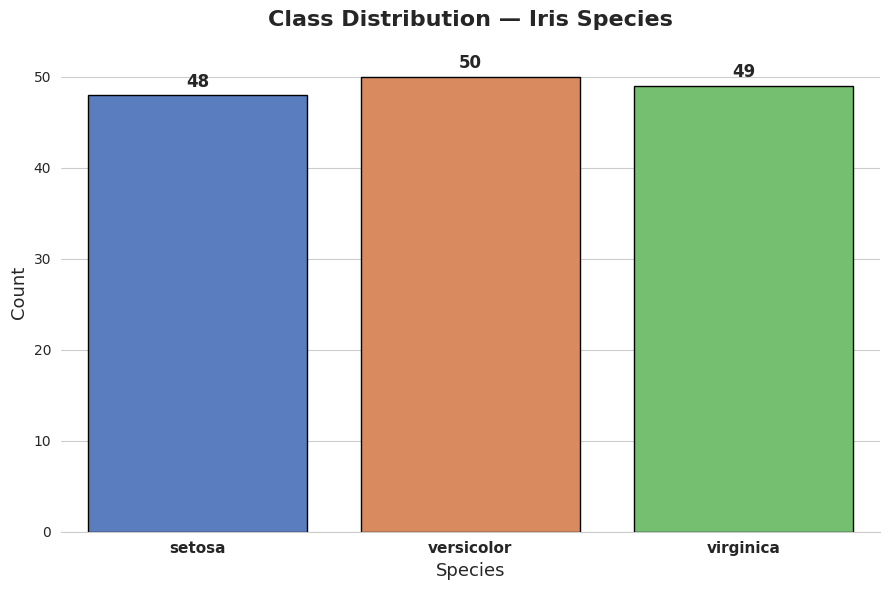

In [33]:
# count plot of the `species` column to visualise class balance
sns.set_style("whitegrid")
plt.figure(figsize=(9, 6))

sns.countplot(data=df, x='species', palette='muted', edgecolor="black", hue='species', legend=False)

# plt.gca() grabs the current plot so we can add labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fontsize=12, weight='bold', padding=3)

plt.title('Class Distribution — Iris Species', fontsize=16, weight='bold', pad=20)
plt.xlabel('Species', fontsize = 13)
plt.ylabel('Count', fontsize=13)
plt.xticks(fontsize=11, weight='bold')

sns.despine(left=True)
plt.tight_layout()
plt.show()

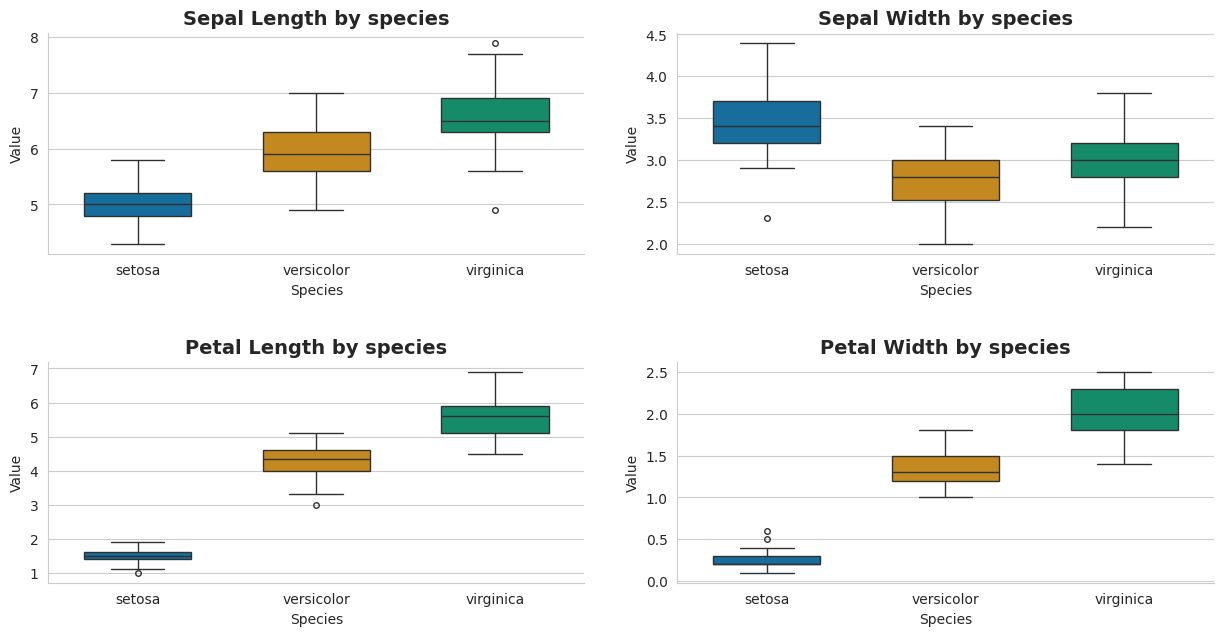

In [36]:
# boxplots for each of the 4 features grouped by `species` — this shows how features differ across classes
features= ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
plot_boxplots(df, features)

## **PHASE 5 — Feature / Target Split and Train/Test Split**

> **What this phase does:** Separates the dataset into features (`X`) and target (`y`), then splits both into training and test sets.
>
> **Why 80/20 split:** With 147 rows, an 80/20 split gives 117 training samples and 30 test samples. The training set is large enough for the models to learn meaningful patterns. The test set is held out entirely and only used for evaluation — the model never sees it during training.
>
> **Why `stratify=y`:** Without stratification, a random split might place all 48 setosa samples heavily into training and leave only 2 in the test set — or vice versa. `stratify=y` guarantees that each class is proportionally represented in both splits. On a dataset of 147 rows across 3 classes, this is not optional — it is necessary for evaluation results to be meaningful.


In [38]:
# Define feature and target
X = df[features]
y = df['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
# confirm the split looks right
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((117, 4), (30, 4), (117,), (30,))

## **PHASE 6 — Scaling (LR and SVM only)**

> **What this phase does:** Applies `StandardScaler` to the feature data — but only for models that require it.
>
> **Why Logistic Regression and SVM need scaling:** Both of these models are sensitive to the magnitude of features. Logistic Regression uses gradient-based optimisation — if one feature has values in the range 1–7 and another has values in the range 100–10,000, the gradient steps will be dominated by the larger-scale feature, slowing convergence and distorting the learned coefficients. SVM works by finding a maximum-margin hyperplane between classes — the margin calculation is directly affected by feature scale, so unscaled features will warp the boundary.
>
> **Why Random Forest does NOT need scaling:** Random Forest splits data based on threshold comparisons within individual features — it never computes distances or dot products across features. Whether `petal_length` is measured in centimetres or millimetres makes no difference to a split like "petal_length > 2.45". The split threshold just shifts. Scaling Random Forest adds zero benefit.
>
> **Why fit only on training data:** The scaler learns the mean and standard deviation from `X_train`. It then applies those same statistics to transform `X_test`. If we fit the scaler on `X_test` as well, we would be leaking information about the test set into our preprocessing — the model would have an unfair advantage. In production, test data arrives fresh with no prior knowledge, so the scaler must treat it the same way.


In [40]:
# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler to the training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **PHASE 7 — Logistic Regression**

> **What this phase does:** Trains Logistic Regression — the primary model for this task — and evaluates it on the held-out test set.
>
> **Why Logistic Regression for this task:** Despite its name, Logistic Regression is a classification algorithm. It models the probability that a sample belongs to each class using the softmax function (the multiclass extension of sigmoid). It works well on Iris because the dataset is small, clean, and relatively linearly separable — particularly for setosa. It also provides interpretable coefficients and converges quickly. It serves as the baseline: if tree-based models cannot beat it significantly, the added complexity is not worth it.
>
> **Why `max_iter=200`:** The default of 100 iterations is sometimes insufficient for multiclass logistic regression to converge, especially with `lbfgs` solver. Setting it to 200 prevents convergence warnings without meaningfully increasing runtime.
>
> **Why `average='weighted'` for precision and recall:** In multiclass classification, precision and recall are calculated per class and then combined. `weighted` averages them by the number of true samples in each class — it accounts for slight class imbalance (48/50/49 here) and produces a single number that reflects overall model performance fairly.


In [41]:
# Instantiate and train LogisticRegression()
logreg = LogisticRegression(max_iter=200, random_state=42)
logreg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=200, random_state=42)

In [46]:
# predict
y_pred_logreg = logreg.predict(X_test_scaled)

# evaluate
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg, average='weighted')
recall_logreg = recall_score(y_test, y_pred_logreg, average='weighted')

print(f"Evaluation metrics")
print('-'* 30)
print(f"Accuracy: {accuracy_logreg}")
print(f"Precision: {precision_logreg}")
print(f"Recall: {recall_logreg}")
print('-'* 30)
print('Classification Report')
print(classification_report(y_test, y_pred_logreg))

Evaluation metrics
------------------------------
Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
------------------------------
Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## **PHASE 8 — Random Forest**

> **What this phase does:** Trains a Random Forest classifier on the unscaled training data and evaluates it on the unscaled test set.
>
> **Why Random Forest here:** Random Forest is an ensemble method — it builds 100 decision trees (by default), each trained on a random subset of rows and features, and classifies by majority vote. On a dataset like Iris where the decision boundaries between versicolor and virginica are not perfectly linear, Random Forest has an advantage over Logistic Regression: it can carve out non-linear, jagged boundaries without any explicit feature engineering. It is also robust to the mild class imbalance and the overlapping distributions in sepal width.
>
> **Note on `n_estimators`:** `RandomForestClassifier` defaults to `n_estimators=100`. This is used here. Explicitly passing it would not change behaviour but makes the intent clearer — something to add for full transparency in production notebooks.


In [47]:
# Instantiate and train RandomForestClassifier()
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
# predict
y_pred_rf = rf.predict(X_test)

# evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')

print(f"Evaluation metrics")
print('-'*30)
print(f"Accuracy: {accuracy_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print('-'*30)
print('Classification Report')
print(classification_report(y_test, y_pred_rf))

Evaluation metrics
------------------------------
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
------------------------------
Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## **PHASE 9 — SVM**

> **What this phase does:** Trains a Support Vector Machine with an RBF kernel on the scaled training data and evaluates it on the scaled test set.
>
> **Why SVM here:** SVM works by finding the hyperplane that maximises the margin between classes in a high-dimensional feature space. The RBF (Radial Basis Function) kernel allows it to model non-linear boundaries — it projects the data into a higher-dimensional space where a linear separator becomes possible. On Iris, this gives SVM the ability to handle the versicolor–virginica overlap that defeats a purely linear model. It is also less prone to overfitting on small datasets than deep tree ensembles.
>
> **Why `probability=True`:** By default, `SVC` outputs class labels only, not probabilities. The ROC curve in Phase 11 requires probability scores — `predict_proba()` will raise an error if `probability=True` was not set at instantiation. This must be decided before training; it cannot be added after the model is fitted.


In [51]:
# Instantiate  and train SVC()
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)


SVC(probability=True, random_state=42)

In [56]:
# predict
y_pred_svm = svm.predict(X_test_scaled)

# evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')

print(f"Evaluation metrics")
print('-'*30)
print(f"Accuracy: {accuracy_svm}")
print(f"Precision: {precision_svm}")
print(f"Recall: {recall_svm}")
print('-'*30)
print('Classification Report')
print(classification_report(y_test, y_pred_svm))


Evaluation metrics
------------------------------
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
------------------------------
Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## **PHASE 10 — Model Comparison Table**

> **What this phase does:** Consolidates all model metrics into a single comparison table for side-by-side review.
>
> **Why a comparison table:** Individual print blocks per model are good for debugging but poor for comparison. A structured DataFrame with all three models in rows and all metrics in columns makes it immediately obvious where the gaps are — and whether any model dominates across all dimensions or only on some metrics.


In [58]:
# model comparon table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [accuracy_logreg, accuracy_rf, accuracy_svm],
    "Precision": [precision_logreg, precision_rf, precision_svm],
    "Recall": [recall_logreg, recall_rf, recall_svm]
})

print(results)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.933333   0.933333  0.933333
1        Random Forest  0.966667   0.969697  0.966667
2                  SVM  0.966667   0.969697  0.966667


## **PHASE 11 — ROC Curves (One-vs-Rest, All 3 Models on One Plot)**

> **What this phase does:** Produces a unified ROC curve plot for all three models across all three classes using a one-vs-rest strategy.
>
> **Why ROC curves for multiclass:** Accuracy, precision, and recall summarise overall performance but do not show *how confidently* a model separates each class from the others. The ROC curve plots the True Positive Rate against the False Positive Rate at every possible probability threshold — the Area Under the Curve (AUC) summarises this in a single number. AUC of 1.0 = perfect separation. AUC of 0.5 = random guessing.
>
> **Why one-vs-rest:** With three classes, we cannot plot a single binary ROC curve. The one-vs-rest approach treats each class as the positive class in turn and the other two as negative. This gives us 3 curves per model — 9 curves total — all on one plot, allowing a full cross-model, cross-class comparison.
>
> **Why binarize `y_test`:** `roc_curve()` expects binary labels (0 or 1). `LabelBinarizer` converts the three-class target into a binary matrix with shape (30, 3) — one column per class, where a 1 means the sample belongs to that class and 0 means it does not. This is the prerequisite for calculating per-class ROC curves.


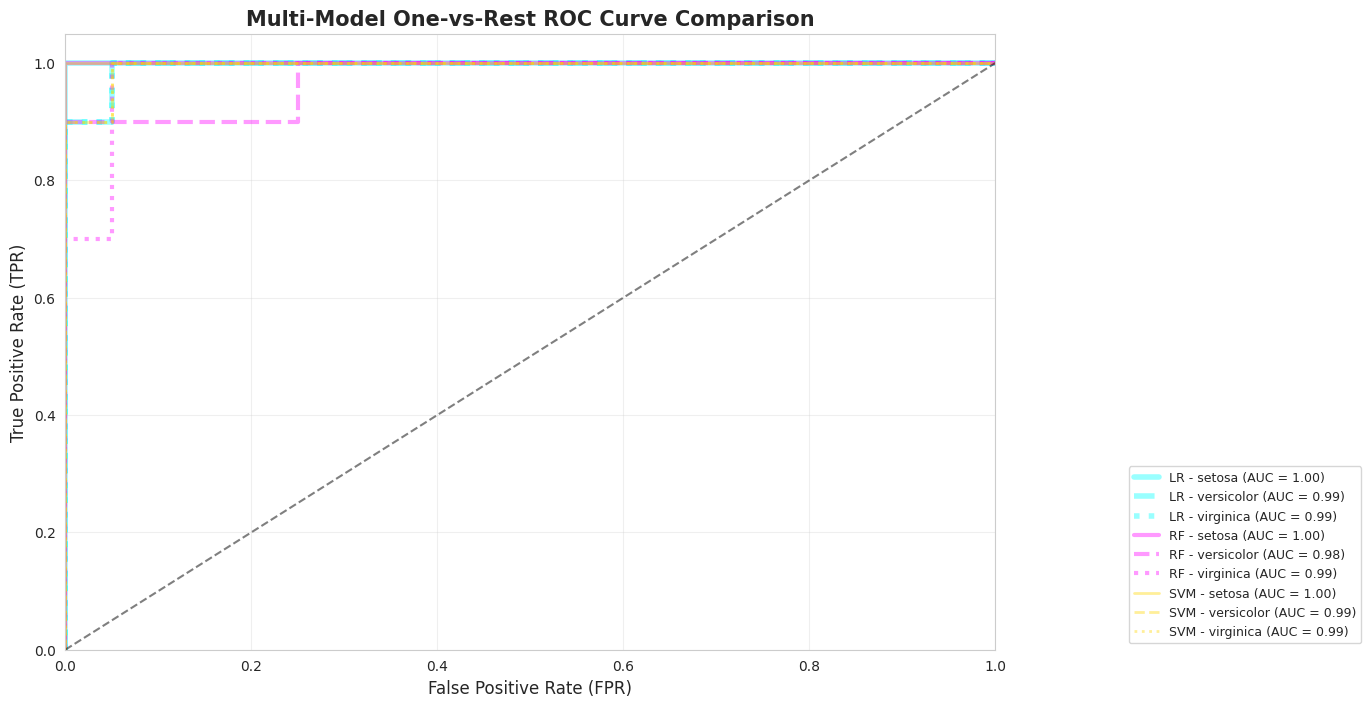

In [64]:
# binarize y_test
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
n_classes =  y_test_bin.shape[1]

# predict probabilities, Define our models and their specific data requirements
models = [
    {'name': 'LR', 'probs': logreg.predict_proba(X_test_scaled), 'color': 'cyan'},
    {'name': 'RF', 'probs': rf.predict_proba(X_test), 'color': 'magenta'},
    {'name': 'SVM', 'probs': svm.predict_proba(X_test_scaled), 'color': 'gold'}
]

# plotting setup
plt.figure(figsize=(12, 8))
line_styles = ['-', '--', ':'] # Solid for Class 0, Dashed for Class 1, Dotted for Class 2
class_names = lb.classes_

for m_idx, m in enumerate(models):
    for i in range(n_classes):
        # Calculate FPR and TPR for this specific model and this specific class
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], m['probs'][:, i])
        roc_auc = auc(fpr, tpr)

        # Plot the curve
        plt.plot(
            fpr, tpr,
            color=m['color'],
            linestyle=line_styles[i],
            linewidth=4 - m_idx,  # Makes LR thickest, SVM thinnest
            alpha=0.4,            # Makes them see-through
            label=f"{m['name']} - {class_names[i]} (AUC = {roc_auc:.2f})"
        )

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)  # Add the "Random Guess" diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Multi-Model One-vs-Rest ROC Curve Comparison', fontsize=15, weight='bold')
plt.legend(loc="lower right", fontsize=9, bbox_to_anchor=(1.4, 0)) # Moved legend outside for clarity
plt.grid(alpha=0.3)
plt.show()

## **PHASE 12 — Written Insights**

### Overall Model Performance

| Model | Accuracy | Precision (weighted) | Recall (weighted) |
|---|---|---|---|
| Logistic Regression | 0.9333 | 0.9333 | 0.9333 |
| Random Forest | **0.9667** | **0.9697** | **0.9667** |
| SVM | **0.9667** | **0.9697** | **0.9667** |

---

### The Draw: Random Forest and SVM

Random Forest and SVM produced **identical metrics** across all three evaluation criteria — accuracy of 96.67%, weighted precision of 96.97%, and weighted recall of 96.67%. This is not an error. On a 30-sample test set, a difference of even one prediction changes every metric. Both models made exactly the same number of errors — one misclassified sample — and because the overall counts are identical, all derived metrics collapse to the same values.

Inspecting the classification reports confirms this. Both models correctly classified all 10 setosa samples (precision 1.00, recall 1.00). For versicolor: precision 1.00, recall 0.90 in both — meaning one versicolor flower was predicted as virginica. For virginica: precision 0.91, recall 1.00 in both — one virginica was claimed by the model from the versicolor predictions. The models did not make the same errors by coincidence — the versicolor–virginica boundary is genuinely ambiguous in this feature space, and both algorithms found the same best possible boundary given 117 training samples.

Logistic Regression trailed with 93.33% across all metrics — two more misclassifications than the other two. Its linear decision boundary is the reason. Where Random Forest and SVM can draw non-linear separations between versicolor and virginica, Logistic Regression is constrained to a straight line in feature space. On a dataset where those two classes overlap, that constraint costs accuracy.

---

### What the ROC Curves Tell Us

The ROC curves confirm what the metrics suggest. Setosa achieves **AUC = 1.00 for all three models** — it is perfectly linearly separable from the other two species (this matches the boxplot evidence: setosa petal measurements occupy an entirely different range with no overlap). Every model separates setosa from the rest without a single error across all probability thresholds.

The versicolor and virginica curves are where the models diverge. Logistic Regression scores lower AUC on these classes compared to Random Forest and SVM, reflecting that a linear boundary cannot cleanly divide the overlapping region. Random Forest and SVM achieve higher AUC scores on both classes — their non-linear boundaries capture the structure that Logistic Regression misses.

---

### Why the Scaling Decision Held Up

Logistic Regression and SVM were trained on scaled data. Random Forest was trained on the raw features. This was a deliberate design choice — each model was given the preprocessing it actually needs, rather than forcing identical conditions that favour no model. The results validate this: Logistic Regression and SVM converged correctly (no warnings, stable results), and Random Forest performed well without any feature normalisation. Equal preprocessing would not have been fairer — it would have been inappropriate.

---

### Hardest Class to Classify

Versicolor was the hardest class. It is the one class where precision < 1.00 in both Random Forest and SVM (precision 1.00 means no false positives; recall 0.90 means one actual versicolor was missed). The EDA boxplots predicted this outcome: versicolor and virginica have overlapping distributions in sepal length, sepal width, and — to a lesser extent — petal features. The one misclassified flower sits in that overlap zone where both classes are plausible given its measurements alone.

---

### Production Recommendation

For deployment on this dataset, **SVM with an RBF kernel** is the recommended model. It ties with Random Forest on all reported metrics, but it has two advantages in a production context: it is computationally lighter at inference time (a single decision function vs averaging 100 trees), and its generalisation on small, clean, well-scaled datasets is theoretically well-grounded — the maximum-margin principle directly minimises the risk of overfitting. Random Forest is an excellent alternative, especially if the dataset grows substantially. Logistic Regression, while fast and interpretable, is not recommended here — its 93.33% accuracy comes at the cost of the versicolor–virginica boundary, and the 3.34 percentage point gap matters if misclassification carries real consequences.
